In [ ]:
install.packages("geojsonio")

In [2]:
library(lidR)
library(ggplot2)
library(terra) # writing raster to file
library(raster)
library(sf) # converting lat/lon to utm
library(gstat) # using kriging algor for DTM
library(patchwork) # plotting box plots with 2nd y-axis
library(dplyr)
library(stringr)

Warning message:
"package 'lidR' was built under R version 4.3.3"
Warning message:
"package 'ggplot2' was built under R version 4.3.3"
Warning message:
"package 'terra' was built under R version 4.3.3"
terra 1.8.29


Attaching package: 'terra'


The following objects are masked from 'package:lidR':

    area, crs, crs<-, is.empty, watershed


Warning message:
"package 'raster' was built under R version 4.3.3"
Loading required package: sp

Warning message:
"package 'sp' was built under R version 4.3.3"

Attaching package: 'sp'


The following object is masked from 'package:lidR':

    wkt



Attaching package: 'raster'


The following objects are masked from 'package:lidR':

    projection, projection<-


Warning message:
"package 'sf' was built under R version 4.3.3"
Linking to GEOS 3.11.2, GDAL 3.8.2, PROJ 9.3.1; sf_use_s2() is TRUE


Attaching package: 'sf'


The following object is masked from 'package:lidR':

    st_concave_hull


Warning message:
"package 'gstat' was built under R

In [3]:
#ptcloud <- "C:/Users/leila/Dropbox/MayoWetlands/pointcloud_processing/ptclouds/CCA_ptcloud" # nolint
#dir <- "C:/Users/leila/Dropbox/MayoWetlands/pointcloud_processing/CCA/"
#dir_gnss <- "C:/Users/leila/Dropbox/MayoWetlands/DroneSurveys/07_11_2025_CCA/GNSS/rover"  # nolint

ptcloud <- "W:/leila/pointcloud processing files/ptclouds/VGB_ptcloud"
dir <- "W:/leila/pointcloud processing files/VGB/"
dir_gnss <- "W:/leila/DroneSurveys/07_11_2025_CCA/GNSS/rover/"

### Step 0: Filter Noise

  |====================================================================  |  98%
 Checking headers consistency
  - Checking file version consistency... ✓
  - Checking scale consistency... ✓
  - Checking offset consistency...
    ⚠ Inconsistent offsets
  - Checking point type consistency... ✓
  - Checking VLR consistency... ✓
  - Checking CRS consistency... ✓
 Checking the headers
  - Checking scale factor validity... ✓
  - Checking Point Data Format ID validity... ✓
 Checking preprocessing already done 
  - Checking negative outliers... ✓
  - Checking normalization... no
 Checking the geometry
  - Checking overlapping tiles... ✓
  - Checking point indexation... noclass       : LAScatalog (v1.2 format 2)
extent      : 327148.1, 328146.8, 1049757, 1050545 (xmin, xmax, ymin, ymax)
coord. ref. : NAD83 / Yukon Albers 
area        : 435652.8 m²
points      : 225.43 million points
density     : 517.5 points/m²
density     : 517.5 pulses/m²
num. files  : 46 
proc. opt.  : buffer: 30 | chunk: 0


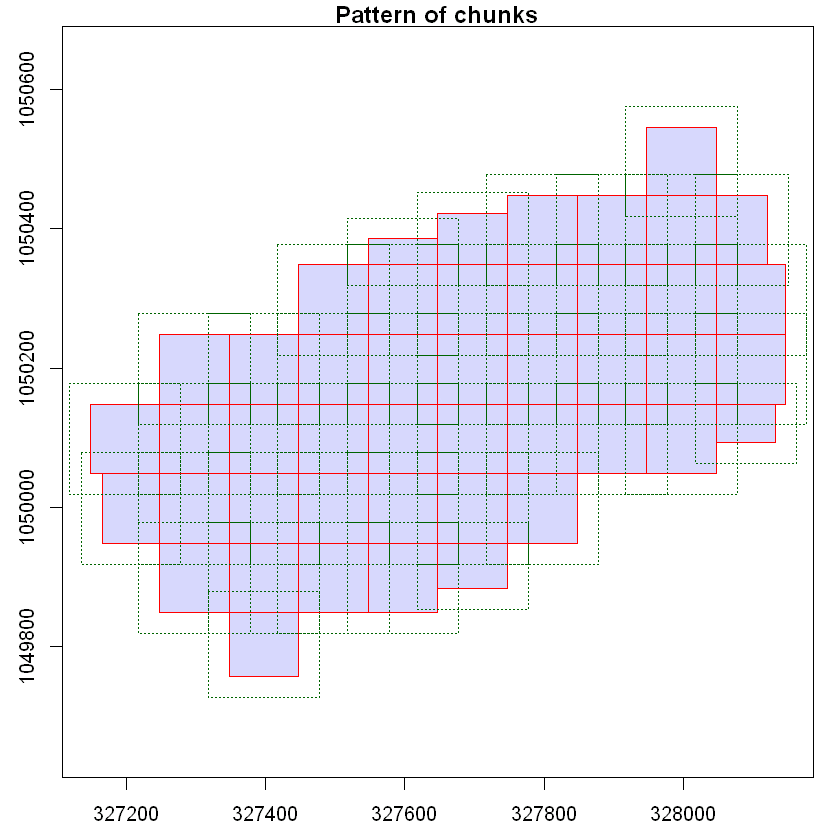

In [4]:
# Read in all tiles as a lascatalog
lasctg <- readLAScatalog(ptcloud)
las_check(lasctg)
summary(lasctg)
plot(lasctg, chunk = TRUE)

Chunk 1 of 46 (2.2%): state ✓
Chunk 2 of 46 (4.3%): state ✓
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓
Chunk 6 of 46 (13%): state ✓
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): state ✓
Chunk 12 of 46 (26.1%): state ✓
Chunk 13 of 46 (28.3%): state ✓
Chunk 14 of 46 (30.4%): state ✓
Chunk 15 of 46 (32.6%): state ✓
Chunk 16 of 46 (34.8%): state ✓
Chunk 17 of 46 (37%): state ✓
Chunk 18 of 46 (39.1%): state ✓
Chunk 19 of 46 (41.3%): state ✓
Chunk 20 of 46 (43.5%): state ✓
Chunk 21 of 46 (45.7%): state ✓
Chunk 22 of 46 (47.8%): state ✓
Chunk 23 of 46 (50%): state ✓
Chunk 24 of 46 (52.2%): state ✓
Chunk 25 of 46 (54.3%): state ✓
Chunk 26 of 46 (56.5%): state ✓
Chunk 27 of 46 (58.7%): state ✓
Chunk 28 of 46 (60.9%): state ✓
Chunk 29 of 46 (63%): state ✓
Chunk 30 of 46 (65.2%): state ✓
Chunk 31 of 46 (67.4%): state ✓
Chunk 32 of 46 (69.6%): state

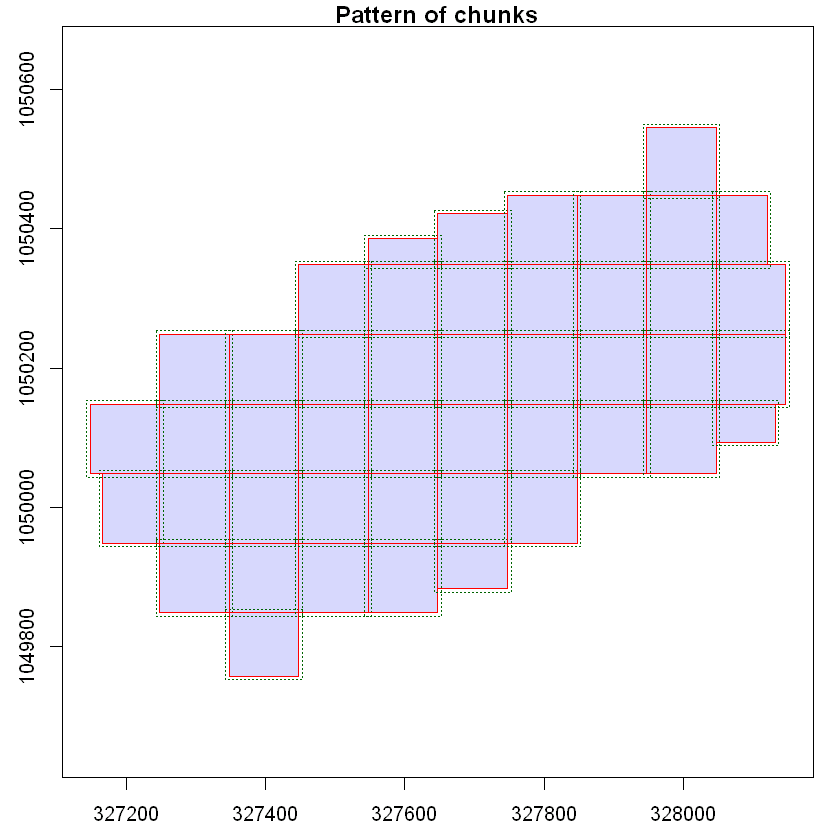

In [5]:
opt_chunk_size(lasctg) <- 0 # process one chunk at a time
opt_chunk_buffer(lasctg) <- 5
opt_output_files(lasctg) <- paste0(dir, "/denoised/{ORIGINALFILENAME}_denoised")
lasctg@output_options$drivers$Raster$param$overwrite <- TRUE # set overwrite to true for repeated processing #nolinter

# classiy noise
las_noise <- classify_noise(lasctg, sor(k = 10, m = 1, quantile = TRUE))

### Step 1: Classify ground points

  |====================================================================  |  98%
 Checking headers consistency
  - Checking file version consistency... ✓
  - Checking scale consistency... ✓
  - Checking offset consistency...
    ⚠ Inconsistent offsets
  - Checking point type consistency... ✓
  - Checking VLR consistency... ✓
  - Checking CRS consistency... ✓
 Checking the headers
  - Checking scale factor validity... ✓
  - Checking Point Data Format ID validity... ✓
 Checking preprocessing already done 
  - Checking negative outliers... ✓
  - Checking normalization... no
 Checking the geometry
  - Checking overlapping tiles... ✓
  - Checking point indexation... noChunk 1 of 46 (2.2%): state ✓
Chunk 2 of 46 (4.3%): state ✓
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓
Chunk 6 of 46 (13%): state ✓
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): 

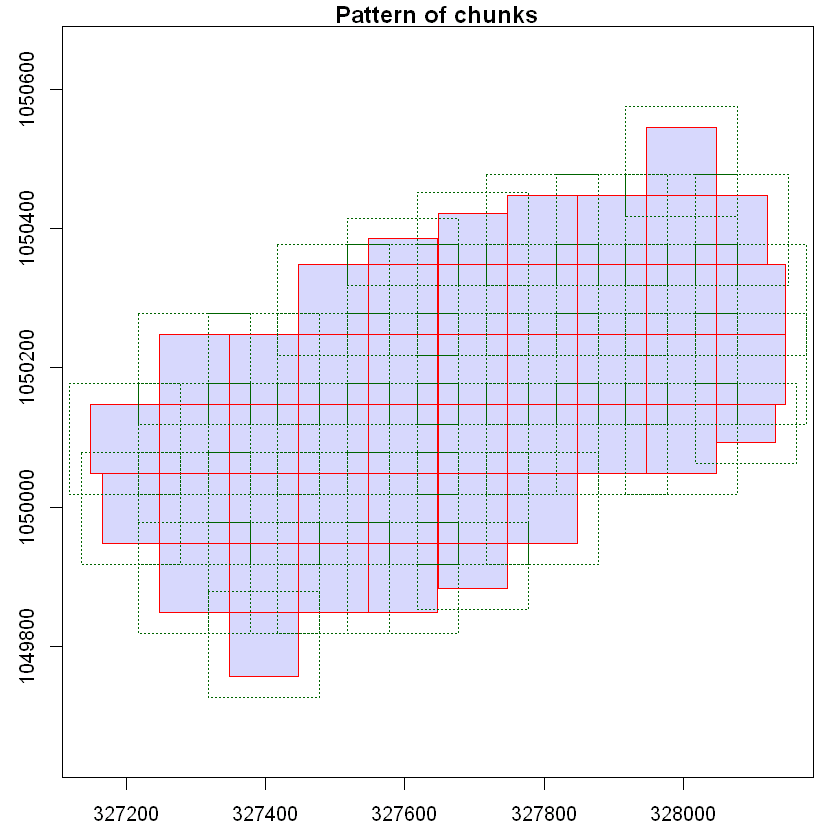

In [6]:
# Read in the points with removied noise
lasctg_denoised <- readLAScatalog(paste0(dir, "/denoised")) #doesn't change
lasctg <- lasctg_denoised  
las_check(lasctg)

opt_output_files(lasctg) <- paste0(dir, "/csf_processed/{ORIGINALFILENAME}_CSF_results")

# classify ground using csf() default 
lasctg <- classify_ground(lasctg, csf())

#### Check the classification *****not working for now

In [2]:
csflas <- readLAScatalog(paste0(dir, "/csf_processed/"))
plot(csflas)

# Read in an area
# MCC
lat <- 63.8299408
lon <- -134.6995430 

# convert to utm 
utm_point <- st_transform(st_sfc(st_point(c(lon, lat)), crs = 4326), crs = 32608)
print(sf::st_as_text(utm_point)) 
# create a circle 
roi <- clip_circle(csflas, x = st_coordinates(utm_point)[1], y = st_coordinates(utm_point)[2], radius = 20)
plot(roi, bg = "white", size = 4)
plot(sf::st_geometry(utm_point))


ERROR: Error in readLAScatalog(paste0(dir, "/csf_processed/")): could not find function "readLAScatalog"


### Step 2: Create the DTM

  |====================================================================  |  98%Chunk 1 of 46 (2.2%): state ✓
Chunk 2 of 46 (4.3%): state ✓
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓
Chunk 6 of 46 (13%): state ✓
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): state ✓
Chunk 12 of 46 (26.1%): state ✓
Chunk 13 of 46 (28.3%): state ✓
Chunk 14 of 46 (30.4%): state ✓
Chunk 15 of 46 (32.6%): state ✓
Chunk 16 of 46 (34.8%): state ✓
Chunk 17 of 46 (37%): state ✓
Chunk 18 of 46 (39.1%): state ✓
Chunk 19 of 46 (41.3%): state ✓
Chunk 20 of 46 (43.5%): state ✓
Chunk 21 of 46 (45.7%): state ✓
Chunk 22 of 46 (47.8%): state ✓
Chunk 23 of 46 (50%): state ✓
Chunk 24 of 46 (52.2%): state ✓
Chunk 25 of 46 (54.3%): state ✓
Chunk 26 of 46 (56.5%): state ✓
Chunk 27 of 46 (58.7%): state ✓
Chunk 28 of 46 (60.9%): state ✓
Chunk 29 of 46 (63%): state ✓
Chunk 30 of 46

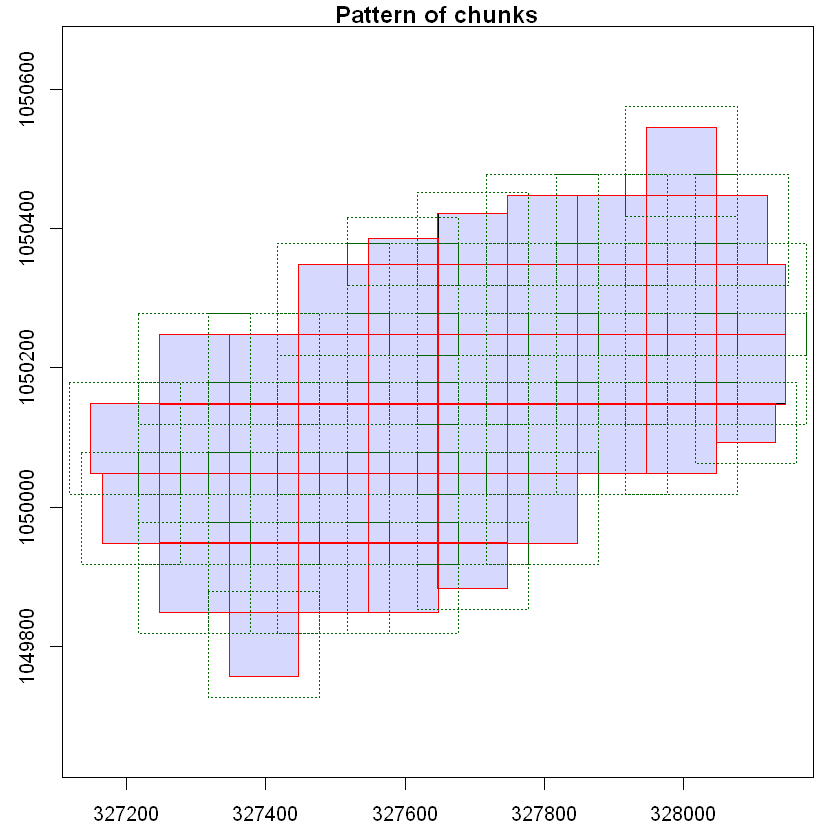

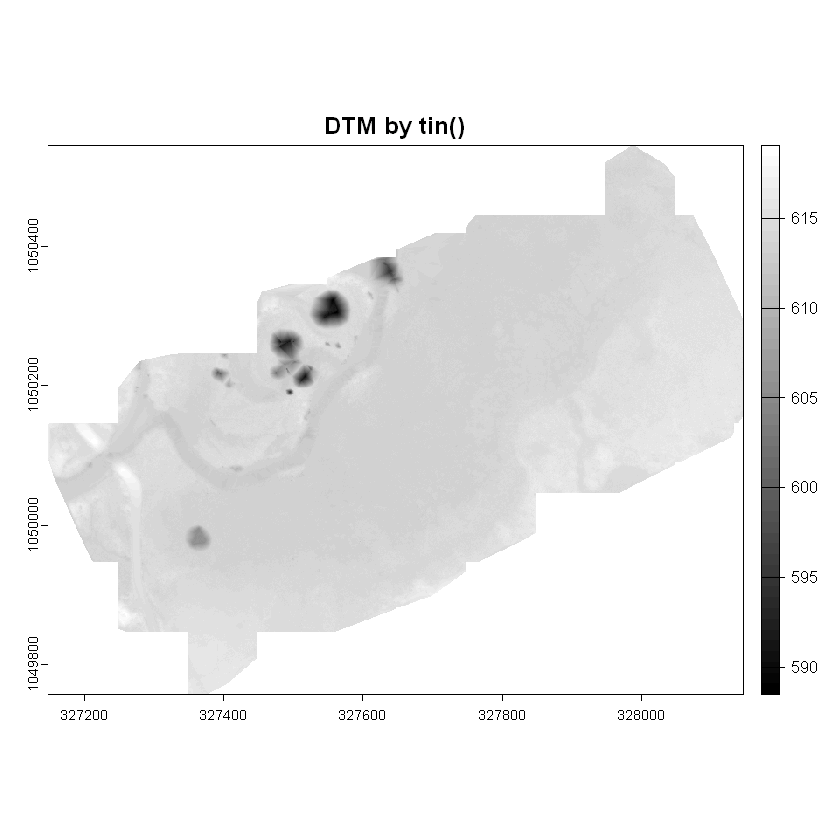

In [7]:
ctg <- readALSLAScatalog(paste0(dir, "/csf_processed/"))

dtm <- rasterize_terrain(ctg, 0.25, tin(), overwrite = TRUE)
plot(dtm, col = gray(0:50/50), main = "DTM by tin()")

In [8]:
# write to file 
writeRaster(dtm, 
            filename = paste0(dir, "/VGB_dtm", ".tif"),
            filetype = "GTiff", 
            overwrite = TRUE)

### Step 3: Normalize the point cloud

In [9]:
# read in the denoised pt cloud tiles and dtm
ctg <- readLAScatalog(paste0(dir, "/denoised"))
dtm <- rast(paste0(dir, "/VGB_dtm.tif"))

# Define where the normalized point cloud tile dir
opt_output_files(ctg) <- paste0(dir, "/normalized_25cm/{ORIGINALFILENAME}_norm")

  |====================================================================  |  98%

In [7]:
las

class        : LAS (v1.4 format 8)
memory       : 759.3 Mb 
extent       : 459391.1, 459551, 7074237, 7074367 (xmin, xmax, ymin, ymax)
coord. ref.  : WGS 84 / UTM zone 8N 
area         : 20784 m²
points       : 8.65 million points
density      : 416.39 points/m²
density      : 416.39 pulses/m²

Chunk 1 of 46 (2.2%): state ✓


Warning message:
"7 points do not belong in the raster. Nearest neighbor was used to assign a value."


Chunk 2 of 46 (4.3%): state ⚠
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓


Warning message:
"2561 points do not belong in the raster. Nearest neighbor was used to assign a value."


Chunk 6 of 46 (13%): state ⚠
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): state ✓
Chunk 12 of 46 (26.1%): state ✓
Chunk 13 of 46 (28.3%): state ✓
Chunk 14 of 46 (30.4%): state ✓
Chunk 15 of 46 (32.6%): state ✓


...

Chunk 45 of 46 (97.8%): state ⚠
Chunk 46 of 46 (100%): state ✓

 Checking headers consistency
  - Checking file version consistency... ✓
  - Checking scale consistency... ✓
  - Checking offset consistency...
    ⚠ Inconsistent offsets
  - Checking point type consistency... ✓
  - Checking VLR consistency... ✓
  - Checking CRS consistency... ✓
 Checking the headers
  - Checking scale factor validity... ✓
  - Checking Point Data Format ID validity... ✓
 Checking preprocessing already done 
  - Checking negative outliers...
    ⚠ 46 file(s) with points below 0
  - Checking normalization... no
 Checking the geometry
  - Checking overlapping tiles... ✓
  - Checking point indexation... no

[1] NA

[1] "PROJCRS[\"NAD83 / Yukon Albers\",\n    BASEGEOGCRS[\"NAD83\",\n        DATUM[\"North American Datum 1983\",\n            ELLIPSOID[\"GRS 1980\",6378137,298.257222101,\n                LENGTHUNIT[\"metre\",1]]],\n        PRIMEM[\"Greenwich\",0,\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        ID[\"EPSG\",4269]],\n    CONVERSION[\"Yukon Albers\",\n        METHOD[\"Albers Equal Area\",\n            ID[\"EPSG\",9822]],\n        PARAMETER[\"Latitude of false origin\",59,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8821]],\n        PARAMETER[\"Longitude of false origin\",-132.5,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8822]],\n        PARAMETER[\"Latitude of 1st standard parallel\",61.6666666666667,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8823]],\n        PARAMETER[\"Latitude of 2nd standard parallel\",68,\n            ANGLEUNIT[\"degree\",0.0174532925199433],\n            ID[\"EPSG\",8824]],\n        PARAMETER[\"Easting at false origin\",500000,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8826]],\n        PARAMETER[\"Northing at false origin\",500000,\n            LENGTHUNIT[\"metre\",1],\n            ID[\"EPSG\",8827]]],\n    CS[Cartesian,2],\n        AXIS[\"(E)\",east,\n            ORDER[1],\n            LENGTHUNIT[\"metre\",1]],\n        AXIS[\"(N)\",north,\n            ORDER[2],\n            LENGTHUNIT[\"metre\",1]],\n    USAGE[\n        SCOPE[\"Territory-wide spatial data management.\"],\n        AREA[\"Canada - Yukon.\"],\n        BBOX[59.99,-141.01,69.7,-123.91]],\n    ID[\"EPSG\",3578]]"

SpatExtent : 327148, 328146.75, 1049757, 1050545.25 (xmin, xmax, ymin, ymax)

SpatExtent : 327148.12, 328146.77, 1049757.19, 1050545.17 (xmin, xmax, ymin, ymax)

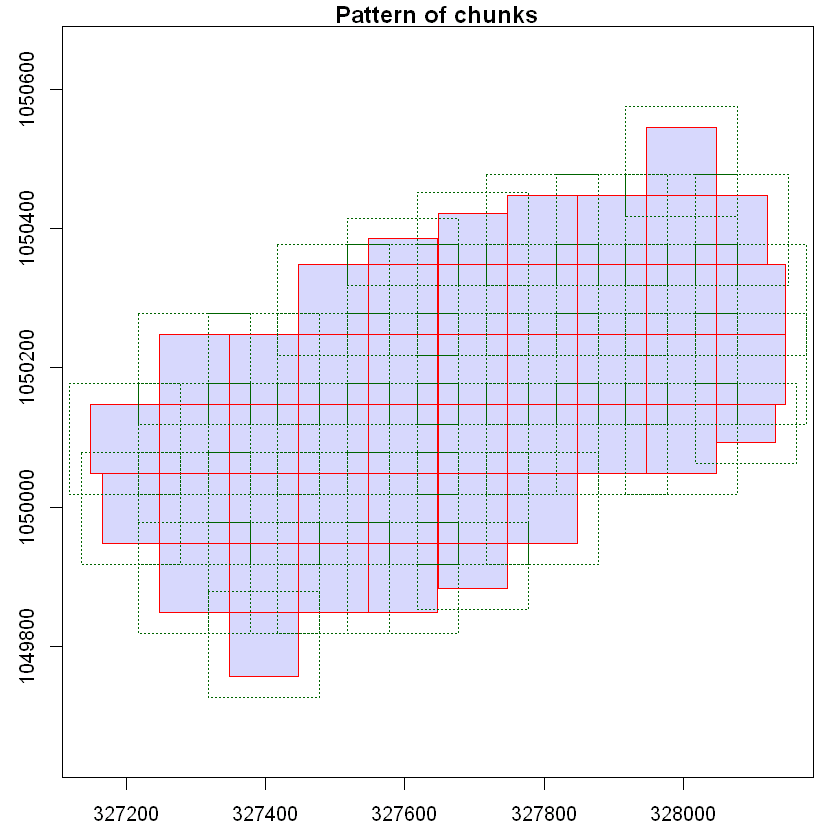

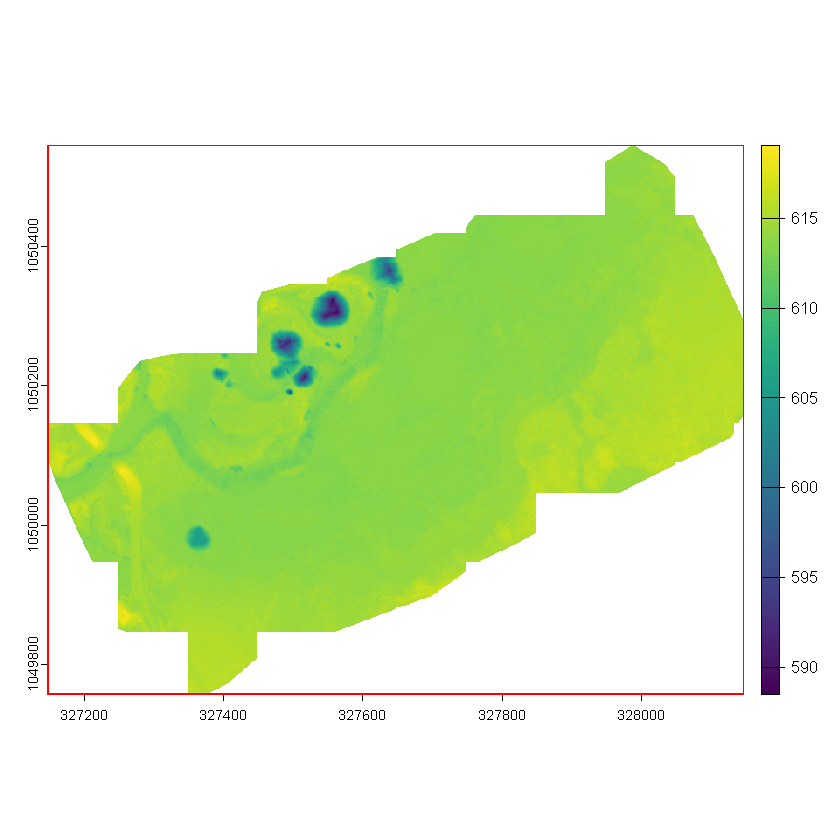

In [10]:
# Normalize points to the dtm surface
ctg_norm <- normalize_height(ctg, dtm)
las_check(ctg_norm)
# due to 1/2 cm differences in extents some points fall outside of the dtm 
#not considered an issue for our purposes 
crs(ctg); crs(dtm)              # must be identical
ext(dtm)                           # DTM extent
ext(ctg)                        # LAS extent (lidR defines this)
plot(dtm); plot(ext(ctg), add=TRUE, border="red", lwd=2)  # overlap?

Chunk 1 of 46 (2.2%): state ✓
Chunk 2 of 46 (4.3%): state ✓
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓
Chunk 6 of 46 (13%): state ✓
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): state ✓
Chunk 12 of 46 (26.1%): state ✓
Chunk 13 of 46 (28.3%): state ✓
Chunk 14 of 46 (30.4%): state ✓
Chunk 15 of 46 (32.6%): state ✓
Chunk 16 of 46 (34.8%): state ✓
Chunk 17 of 46 (37%): state ✓
Chunk 18 of 46 (39.1%): state ✓
Chunk 19 of 46 (41.3%): state ✓
Chunk 20 of 46 (43.5%): state ✓
Chunk 21 of 46 (45.7%): state ✓
Chunk 22 of 46 (47.8%): state ✓
Chunk 23 of 46 (50%): state ✓
Chunk 24 of 46 (52.2%): state ✓
Chunk 25 of 46 (54.3%): state ✓
Chunk 26 of 46 (56.5%): state ✓
Chunk 27 of 46 (58.7%): state ✓
Chunk 28 of 46 (60.9%): state ✓
Chunk 29 of 46 (63%): state ✓
Chunk 30 of 46 (65.2%): state ✓
Chunk 31 of 46 (67.4%): state ✓
Chunk 32 of 46 (69.6%): state

class       : LAScatalog (v1.2 format 2)
extent      : 327148.1, 328146.8, 1049757, 1050545 (xmin, xmax, ymin, ymax)
coord. ref. : NAD83 / Yukon Albers 
area        : 435472.6 m²
points      : 160.24 million points
density     : 368 points/m²
density     : 368 pulses/m²
num. files  : 46 


 Checking headers consistency
  - Checking file version consistency... ✓
  - Checking scale consistency... ✓
  - Checking offset consistency...
    ⚠ Inconsistent offsets
  - Checking point type consistency... ✓
  - Checking VLR consistency... ✓
  - Checking CRS consistency... ✓
 Checking the headers
  - Checking scale factor validity... ✓
  - Checking Point Data Format ID validity... ✓
 Checking preprocessing already done 
  - Checking negative outliers...
    ⚠ 46 file(s) with points below 0
  - Checking normalization... no
 Checking the geometry
  - Checking overlapping tiles... ✓
  - Checking point indexation... no

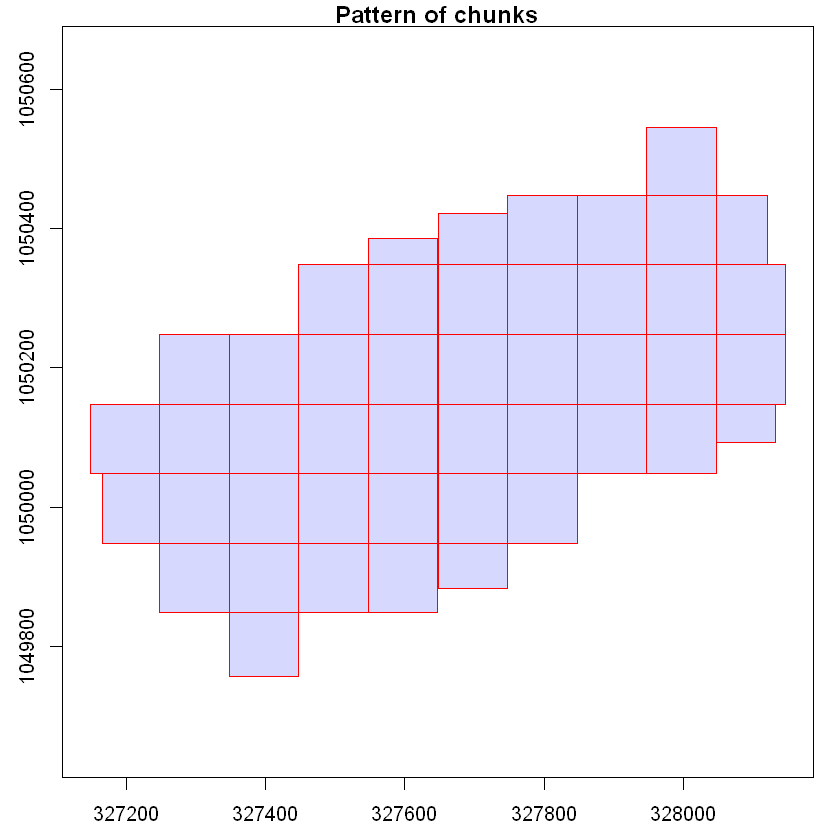

In [11]:
# If there are outlier negative points
# bring them to 0 
opt_output_files(ctg_norm) <- paste0(dir, "/normalized_no_neg_25/{ORIGINALFILENAME}_norm_noneg")
opt_filter(ctg_norm) <- "-drop_z_below 0"
#opt_chunk_size(ctg_norm) <- 0    # set your desired tile size here
opt_chunk_buffer(ctg_norm) <- 0    # no overlap

catalog_retile(ctg_norm)
las_check(ctg_norm)

##### Step 3.1: Compare normalized point cloud with measured tree heights

Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓
Chunk 1 of 1 (100%): state ✓


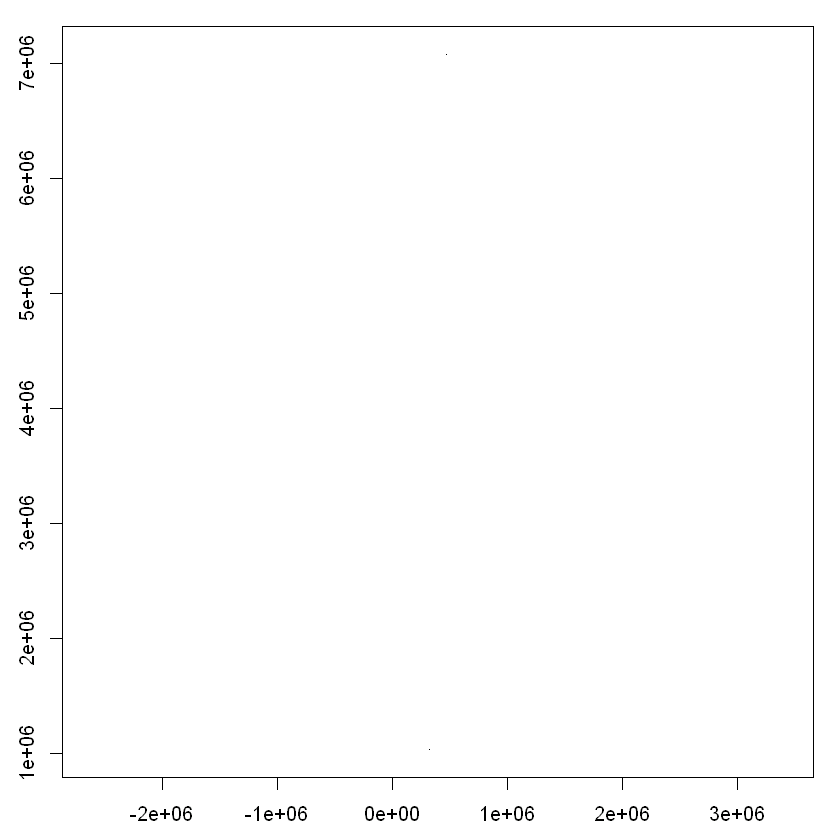

Chunk 1 of 1 (100%): state ✓


[1] 2.001 1.311 1.311 1.311 5.602 0.174

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.137   0.272   1.311   2.564   4.615   8.802 

[1] "topo"       "topo"       "topo"       "topo"       "topo"      
 [6] "topo"       "topo1"      "GCP1"       "Topo"       "Topo1"     
[11] "Topo2"      "Topo3"      "Topo4"      "GCP"        "Tree_12.2m"
[16] "Topo-hum"   "Topo"       "Tree_8.0m"  "Topo"       "Topo1"     
[21] "tree_4.2m"  "GCP"        "TOPO"       "TOPO1"      "TOPO2"     
[26] "WELL"       "PIEZO"      "GCP"        "TOPO"       "TOPO1"     
[31] "TOPO2"      "TOPO3"      "TOPO4"      "TOPO5"      "GCP"

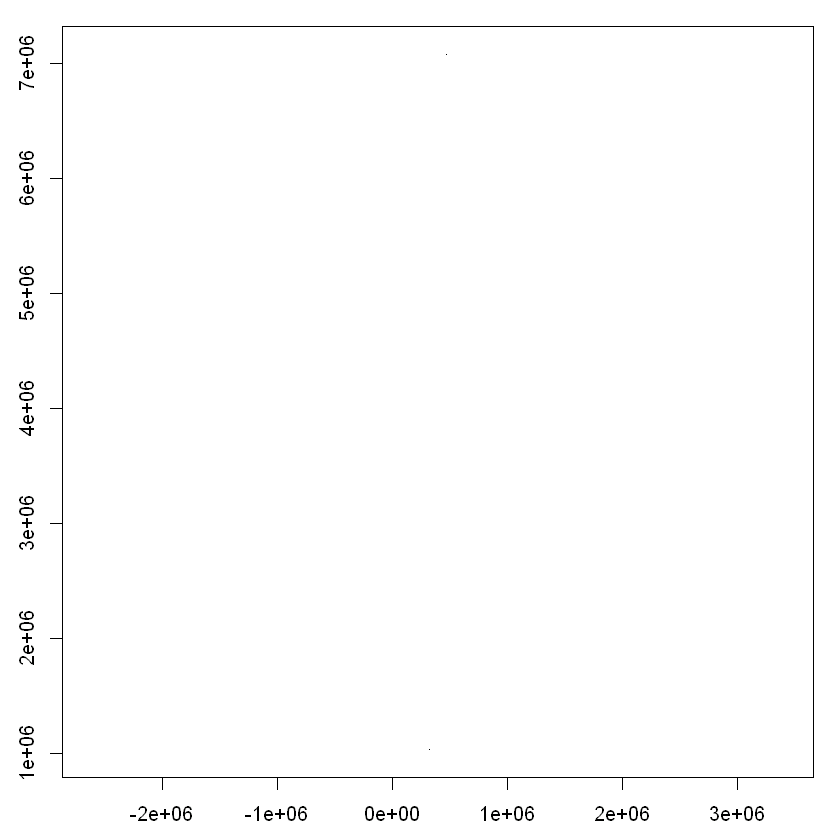

In [ ]:
# Read in GNSS points as Lat/Lon (EPSG:4326) description
gnss <- read.csv(paste0(dir_gnss, "CCA.csv"))
gnss_sf <- st_as_sf(gnss, coords = c("Longitude", "Latitude"), crs = 4326)
ctg <- readLAScatalog(paste0(dir, "/normalized_no_neg_25/"))

# Reproject to UTM Zone 8N
gnss_sf <- st_transform(gnss_sf, crs = 32608)

# Create a 3m buffer 
buffers <- st_buffer(gnss_sf, dist = 3)

# Function for getting the maximum point in that buffer (assuming that is the tree)
get_max_z <- function(buffer_geom) {
  bbox <- st_bbox(buffer_geom)
  las_crop <- clip_roi(ctg, bbox)
  if (is.null(las_crop) || nrow(las_crop@data) == 0) return(NA)
  las_clip <- clip_roi(las_crop, buffer_geom)  
  if (is.null(las_clip) || nrow(las_clip@data) == 0) return(NA)
  return(max(las_clip$Z, na.rm = TRUE))
}

# Apply the function to each buffer 
gnss$tree_top_z <- sapply(1:nrow(buffers), function(i) get_max_z(buffers[i, ]))

head(gnss$tree_top_z)
summary(gnss$tree_top_z)
gnss$Name


In [41]:
# Extract measured height from the description column
gnss$height_m <- as.numeric(stringr::str_extract(gnss$Name, "[0-9.]+(?=\\s*m)"))

# Calculate RMSE
rmse <- sqrt(mean((gnss$tree_top_z - gnss$height_m)^2, na.rm = TRUE))

# Print result
cat("RMSE between SfM-estimated and measured tree heights:", round(rmse, 4), "m\n")

ERROR: Error: object 'gnss' not found


In [78]:
View(gnss[, c("Name", "height_m", "tree_top_z")])

Name,height_m,tree_top_z
<chr>,<dbl>,<dbl>
topo,NA,2.001
topo,NA,1.311
topo,NA,1.311
topo,NA,1.311
topo,NA,5.602
topo,NA,0.174
topo1,NA,0.216
GCP1,NA,0.967
Topo,NA,0.438


### Step 6: Compute metrics on veg struct plot


In [18]:
ptcloud <- "W:/leila/pointcloud processing files/ptclouds/VGB_ptcloud"
dir <- "W:/leila/pointcloud processing files/VGB"

In [19]:
struct_coords <- read.csv("W:/leila/veg indices/veg_struc_coords_2025.csv")
row <- subset(struct_coords, site_code == "VGB")
print(row)
# grab lat/lon (first match)
lat <- as.numeric(row$lat[1])
lon <- as.numeric(row$lon[1])

lat; lon


   site_code      lat       lon
29       VGB 63.89495 -136.0223


[1] 63.89495

[1] -136.0223

Chunk 1 of 1 (100%): state ∅


No point found for within region of interest 1.



ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'print': object 'metrics' not found


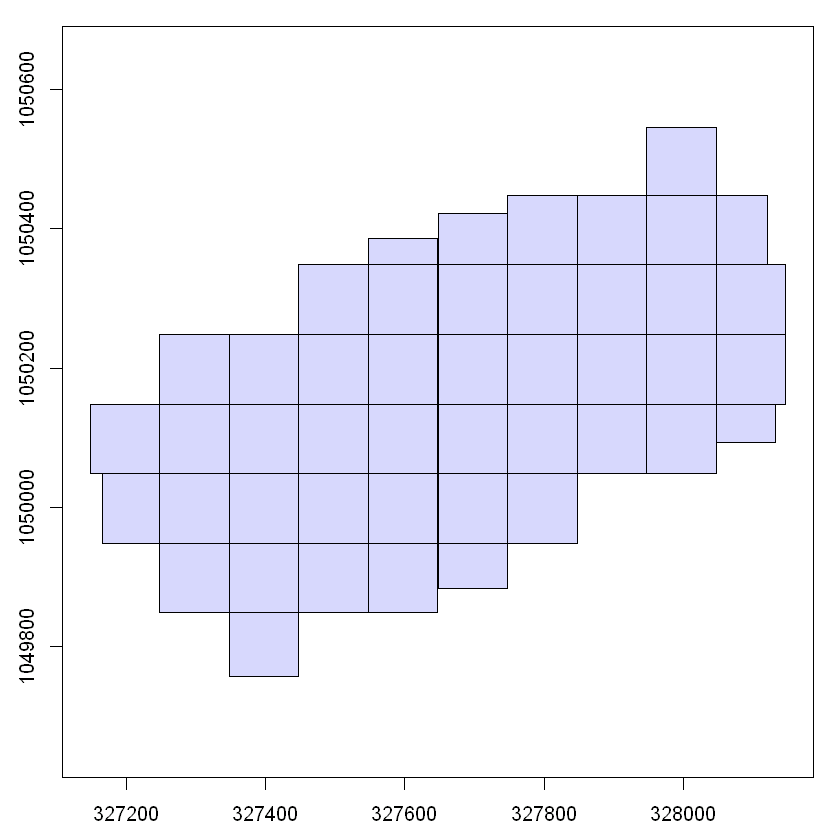

In [28]:
# read in the norm point cloud
ctg <- readLAScatalog(paste0(dir, "/normalized_no_neg_25/"))
pt <- st_sfc(st_point(c(lon, lat)), crs = 4326)
pt_utm <- st_transform(pt, crs = 32608)  
circle <- st_buffer(pt_utm, dist = 10)

# Step 2: Clip the normalized point cloud to the buffer
las_clip <- clip_roi(ctg, circle)

# Check for empty result
# Get Z values (heights above ground) from normalized point cloud
z_vals <- las_clip$Z

# Make sure there are points
if (length(z_vals) > 0) {
  
  # Compute metrics
  metrics <- data.frame(
    Mean = mean(z_vals, na.rm = TRUE),
    Median = median(z_vals, na.rm = TRUE),
    Maximum = max(z_vals, na.rm = TRUE),
    Minimum = min(z_vals, na.rm = TRUE),
    StdDev = sd(z_vals, na.rm = TRUE),
    
    # Height percentiles
    P95 = as.numeric(quantile(z_vals, 0.95, na.rm = TRUE)),
    P75 = as.numeric(quantile(z_vals, 0.75, na.rm = TRUE)),
    P25 = as.numeric(quantile(z_vals, 0.25, na.rm = TRUE)),
    IQR = IQR(z_vals, na.rm = TRUE),
    
    # Canopy cover (aka closure)
    CanopyCover1m = sum(z_vals > 1, na.rm = TRUE) / length(z_vals),
    CanopyCover2m = sum(z_vals > 2, na.rm = TRUE) / length(z_vals)
  )
}
  
print(metrics)

### Step 7: Stem density via locate trees


In [27]:
# read in normalized pt cloud again
#ctg <- readLAScatalog(paste0(dir, "/normalized_no_neg_25/"))
dir_ttops <- "W:/leila/pointcloud processing files/VGB"
ctg <- readLAScatalog("W:/leila/pointcloud processing files/VGB/normalized_no_neg_25")
wetlands <- st_read("W:/leila/Arc projects/wetland_extents_shp_utm_update")
st_crs(wetlands)
st_crs(ctg)

# define the site for the shp file
selected_site <- "VGB"
site_id <- "SiteID"



  |====================================================================  |  98%Reading layer `wetland_extents_utm_update' from data source 
  `W:\leila\Arc projects\wetland_extents_shp_utm_update' using driver `ESRI Shapefile'
Simple feature collection with 26 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 420835.4 ymin: 7019316 xmax: 692177.8 ymax: 7114017
Projected CRS: WGS 84 / UTM zone 8N


Coordinate Reference System:
  User input: WGS 84 / UTM zone 8N 
  wkt:
PROJCRS["WGS 84 / UTM zone 8N",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]],
            ID["EPSG",6326]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["UTM zone 8N",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-135,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["Fal

Coordinate Reference System:
  User input: EPSG:3578 
  wkt:
PROJCRS["NAD83 / Yukon Albers",
    BASEGEOGCRS["NAD83",
        DATUM["North American Datum 1983",
            ELLIPSOID["GRS 1980",6378137,298.257222101,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4269]],
    CONVERSION["Yukon Albers",
        METHOD["Albers Equal Area",
            ID["EPSG",9822]],
        PARAMETER["Latitude of false origin",59,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8821]],
        PARAMETER["Longitude of false origin",-132.5,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8822]],
        PARAMETER["Latitude of 1st standard parallel",61.6666666666667,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8823]],
        PARAMETER["Latitude of 2nd standard parallel",68,
            ANGLEUNIT["degree",0.0174532925199433],
     

In [23]:
opt_chunk_buffer(ctg) <- 10
opt_progress(ctg) <- TRUE
opt_output_files(ctg) <- ""  # do not write to file

Chunk 1 of 46 (2.2%): state ✓
Chunk 2 of 46 (4.3%): state ✓
Chunk 3 of 46 (6.5%): state ✓
Chunk 4 of 46 (8.7%): state ✓
Chunk 5 of 46 (10.9%): state ✓
Chunk 6 of 46 (13%): state ✓
Chunk 7 of 46 (15.2%): state ✓
Chunk 8 of 46 (17.4%): state ✓
Chunk 9 of 46 (19.6%): state ✓
Chunk 10 of 46 (21.7%): state ✓
Chunk 11 of 46 (23.9%): state ✓
Chunk 12 of 46 (26.1%): state ✓
Chunk 13 of 46 (28.3%): state ✓
Chunk 14 of 46 (30.4%): state ✓
Chunk 15 of 46 (32.6%): state ✓
Chunk 16 of 46 (34.8%): state ✓
Chunk 17 of 46 (37%): state ✓
Chunk 18 of 46 (39.1%): state ✓
Chunk 19 of 46 (41.3%): state ✓
Chunk 20 of 46 (43.5%): state ✓
Chunk 21 of 46 (45.7%): state ✓
Chunk 22 of 46 (47.8%): state ✓
Chunk 23 of 46 (50%): state ✓
Chunk 24 of 46 (52.2%): state ✓
Chunk 25 of 46 (54.3%): state ✓
Chunk 26 of 46 (56.5%): state ✓
Chunk 27 of 46 (58.7%): state ✓
Chunk 28 of 46 (60.9%): state ✓
Chunk 29 of 46 (63%): state ✓
Chunk 30 of 46 (65.2%): state ✓
Chunk 31 of 46 (67.4%): state ✓
Chunk 32 of 46 (69.6%): state

Warning message:
"An error occured during the automatic merge of 'catalog_apply'. Merging is impossible. A list has been returned."


ERROR: Error in data.table::rbindlist(any_list): Class attribute on column 3 of item 19 does not match with column 3 of item 1. You can deactivate this safety-check by using ignore.attr=TRUE


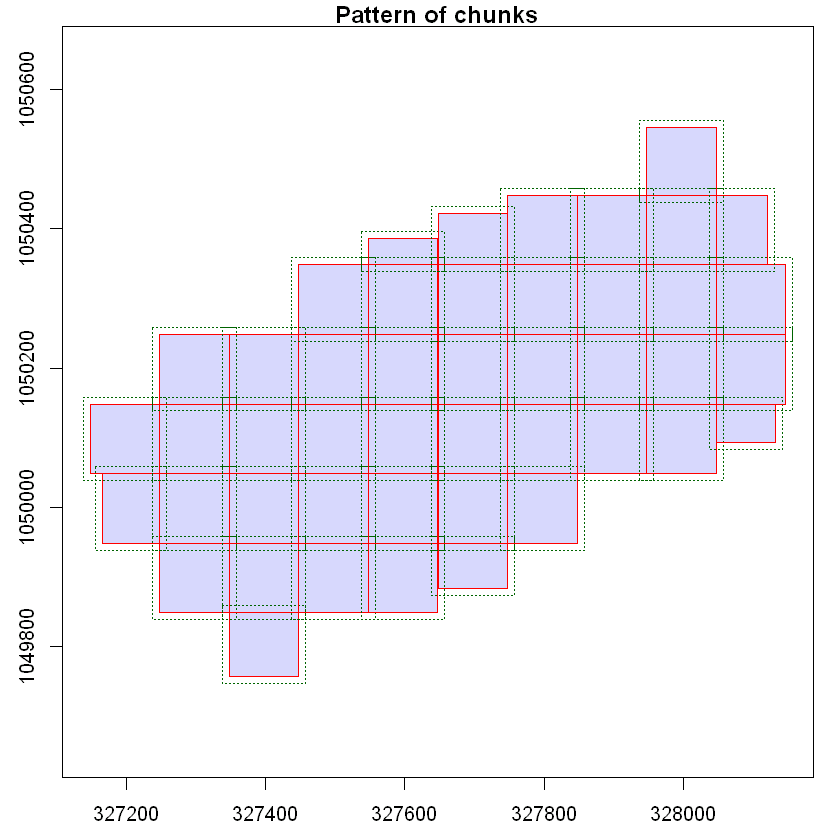

In [26]:
# set-up locate trees function
#ttops <- locate_trees(ctg, lmf(ws = 3), uniqueness = "incremental" )  # stable IDs across chunks/tiles  # tends to be less

fws <- function(h) pmax(1.2, pmin(6, 0.06 * h + 0.8))  # clamp 1.2–6 m                                 # tends to give more
ttops <- locate_trees(ctg, lmf(ws = fws, hmin = 2, shape = "circular"), uniqueness = "incremental")

#fws <- function(h) pmax(1.1, pmin(5.5, 0.05*h + 0.7))  # smaller floor + gentler slope
#ttops <- locate_trees(ctg, lmf(ws = fws, hmin = 1.5, shape = "circular"), uniqueness = "incremental")


In [25]:
ttops

ERROR: Error: object 'ttops' not found


In [17]:
class(wetlands)
class(ttops)


[1] "sf"         "data.frame"

[1] "sf"         "data.table" "data.frame"

In [275]:
ttops

,treeID,Z,geometry
,<int>,<dbl>,<POINT [m]>
1,1,2.08,POINT (483806.6 7100110)
2,2,2.30,POINT (483806.2 7100105)
3,3,2.81,POINT (483814.9 7100108)
4,4,2.41,POINT (483833.8 7100105)
5,5,6.50,POINT (483840.8 7100111)
6,6,5.91,POINT (483842.1 7100109)
7,7,5.39,POINT (483843.8 7100111)
8,8,6.28,POINT (483846.2 7100112)
9,9,6.33,POINT (483843.4 7100106)


In [18]:
# pick one CRS to use everywhere — here we use ttops'
crs_pts <- st_crs(ttops)

# drop any Z/M axis tags (not needed for XY joins) and transform
wetlands <- st_transform(st_zm(wetlands, drop = TRUE), crs_pts)
ttops    <- st_transform(st_zm(ttops,    drop = TRUE), crs_pts)


In [19]:
ttops_site <- st_join(
  ttops,
  wetlands[wetlands[[site_id]] == selected_site, site_id],
  join = st_within,
  left  = FALSE
)


In [20]:
identical(st_crs(wetlands), st_crs(ttops))  # should be TRUE
st_bbox(wetlands); st_bbox(ttops)           # should be same ballpark
nrow(ttops_site)                             # number of treetops in the site


[1] TRUE

     xmin      ymin      xmax      ymax 
 420835.4 7019316.4  692177.8 7114016.5 

     xmin      ymin      xmax      ymax 
 444498.3 7065067.0  444812.0 7065353.7 

[1] 0

In [21]:
site_poly  <- wetlands[wetlands[[site_id]] == selected_site, ]

# strict (inside only)
ttops_site <- sf::st_join(ttops, site_poly[, site_id], join = sf::st_within, left = FALSE)

In [22]:
area_m2 <- as.numeric(sf::st_area(sf::st_union(site_poly)))
n_trees <- nrow(ttops_site)
density_m2 <- n_trees / area_m2
cat(sprintf("Trees: %d | Area: %.1f m² | Density: %.6f trees/m²\n",
            n_trees, area_m2, density_m2))

Trees: 0 | Area: 994.8 m² | Density: 0.000000 trees/m²


In [255]:
library(mapview)
mapview(site_poly, alpha.regions = 0.2) + mapview(ttops, zcol = "Z")


In [23]:
out_gpkg <- file.path(dir_ttops, paste0(selected_site, "_ttops.gpkg"))

# Write to GeoPackage (will overwrite same-layer only)
st_write(ttops_site, out_gpkg, layer = paste0(selected_site, "_ttops"), delete_layer = TRUE)

cat("✅ Exported treetops for site", selected_site, "to:\n", out_gpkg, "\n")

Writing layer `MLE_ttops' to data source 
  `W:/leila/pointcloud processing files/MLE//MLE_ttops.gpkg' using driver `GPKG'
Writing 0 features with 3 fields and geometry type Unknown (any).
✅ Exported treetops for site MLE to:
 W:/leila/pointcloud processing files/MLE//MLE_ttops.gpkg 
